# Imports & paths

In [21]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import timedelta
import joblib
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sksurv.metrics import integrated_brier_score
from sksurv.util import Surv

DATA_INTERIM = Path("../data/interim")
DATA_PROCESSED = Path("../data/processed")
ART_MODELS = Path("../artifacts/models")
ART_SCORES = Path("../artifacts/scores")

# Load data

## Survival 

In [22]:
df_txn = pd.read_parquet(DATA_INTERIM / "transactions_clean.parquet")

In [23]:
surv_df = (
    df_txn
    .groupby("customer_id")["transaction_date"]
    .agg(["min", "max"])
    .reset_index()
    .rename(columns={"min": "first_tx", "max": "last_tx"})
)
surv_df["event_time"] = surv_df["last_tx"] + pd.Timedelta(days=90)
study_end = df_txn["transaction_date"].max()

In [24]:
surv_df["event"] = (surv_df["event_time"] <= study_end).astype(int)

# Duration	= min(churn_time, study_end) − origin
surv_df["duration_days"] = (
    surv_df["event_time"]
        .where(surv_df["event"].eq(1), study_end)
    - surv_df["first_tx"]
).dt.days

In [25]:
surv_df["tenure_days"] = (surv_df["last_tx"] - surv_df["first_tx"]).dt.days.clip(lower=0)
surv_df["recency_at_end"] = (study_end - surv_df["last_tx"]).dt.days.clip(lower=0)

In [26]:
lifetime_agg = (
    df_txn.groupby("customer_id")
    .agg(
        total_txn=("transaction_date", "count"),
        total_amount=("amount", "sum"),
    )
    .reset_index()
)

surv_df = surv_df.merge(lifetime_agg, on="customer_id", how="left")

tenure_months = (surv_df["tenure_days"] / 30.0).clip(lower=1.0)
surv_df["txn_per_month"] = surv_df["total_txn"] / tenure_months
surv_df["amount_per_month"] = surv_df["total_amount"] / tenure_months

In [27]:
end_30 = study_end - timedelta(days=30)
end_90 = study_end - timedelta(days=90)

df_recent = df_txn.assign(
    in_30d=(df_txn["transaction_date"] >= end_30),
    in_90d=(df_txn["transaction_date"] >= end_90),
)

recent_agg = (
    df_recent.groupby("customer_id")
    .agg(
        freq_30d=("in_30d", "sum"),
        freq_90d=("in_90d", "sum"),
    )
    .reset_index()
)

surv_df = surv_df.merge(recent_agg, on="customer_id", how="left")
surv_df[["freq_30d", "freq_90d"]] = surv_df[["freq_30d", "freq_90d"]].fillna(0)

surv_df["freq_ratio_30d_90d"] = surv_df["freq_30d"] / (surv_df["freq_90d"] + 1e-6)

## Gamma

In [28]:
from lifetimes.utils import summary_data_from_transaction_data

summary = summary_data_from_transaction_data(
    df_txn,
    customer_id_col="customer_id",
    datetime_col="transaction_date",
    monetary_value_col="amount",
    observation_period_end=study_end,
    freq="D"
).reset_index()

# Load Model

In [29]:
surv_model = joblib.load(ART_MODELS/"survival_cox.pkl")       
gg_model   = joblib.load(ART_MODELS/"gamma_gamma_model.pkl") 

In [30]:
features = [
    "tenure_days",
    "recency_at_end",
    "txn_per_month",
    "amount_per_month",
    "freq_30d",
    "freq_90d",
    "freq_ratio_30d_90d",
]

## Expected remaining lifetime

In [31]:
T_days = 365
dt = 7
times = np.arange(0, T_days + dt, dt)
X_surv = surv_df[features].copy()

# Predict survival curves from origin
S = surv_model.predict_survival_function(X_surv, times=times)
# S: DataFrame index=times, columns aligned with rows in X_surv

# Define "now" age for each customer (days since origin=first_tx)
study_end = df_txn["transaction_date"].max()
age_now = (study_end - surv_df["first_tx"]).dt.days.values.astype(float)

# Convert to numpy for fast ops + interpolation
t_grid = S.index.values.astype(float)
S_np = S.values  # shape (len(times), N)

future_times = times.astype(float)  # remaining time grid from now (0..T)

# Interpolate S(a) for each customer
S_at_a = np.array([np.interp(a, t_grid, S_np[:, i]) for i, a in enumerate(age_now)])
S_at_a = np.clip(S_at_a, 1e-10, 1.0)

# Conditional survival S_cond(t) = S(a+t)/S(a)
S_cond = np.zeros((len(future_times), S_np.shape[1]))
for i, a in enumerate(age_now):
    S_future = np.interp(a + future_times, t_grid, S_np[:, i])
    S_cond[:, i] = S_future / S_at_a[i]

# Expected remaining lifetime (days) = integral of S_cond(t) dt
surv_df["expected_remaining_lifetime"] = np.trapz(S_cond, x=future_times, axis=0)

## Expected Order Value

In [32]:
summary_gg = summary[summary["monetary_value"] > 0]

summary.loc[summary_gg.index, "expected_avg_order_value"] = (
    gg_model.conditional_expected_average_profit(
        summary_gg["frequency"],
        summary_gg["monetary_value"]
    )
)

# Time-dependent CLV

In [33]:
surv_df = surv_df.merge(
    summary[["customer_id", "monetary_value"]],
    on="customer_id",
    how="right"
)

In [34]:
surv_df

,customer_id,first_tx,last_tx,event_time,event,duration_days,tenure_days,recency_at_end,total_txn,total_amount,txn_per_month,amount_per_month,freq_30d,freq_90d,freq_ratio_30d_90d,expected_remaining_lifetime,monetary_value
0,C00000,2025-09-10,2025-12-31,2026-03-31,0,112,112,0,12,1222.85,3.214286,327.549107,4,9,0.444444,47.796846,93.370000
1,C00001,2025-03-17,2025-12-20,2026-03-20,0,289,278,11,19,1228.46,2.050360,132.567626,3,8,0.375000,200.138244,68.373529
2,C00002,2025-08-20,2025-09-26,2025-12-25,1,127,37,96,11,910.64,8.918919,738.356757,0,0,0.000000,5.319576,86.307778
3,C00003,2025-10-04,2025-11-18,2026-02-16,0,88,45,43,4,114.71,2.666667,76.473333,0,4,0.000000,37.578041,19.393333
4,C00004,2025-06-08,2025-09-14,2025-12-13,1,188,98,108,19,2018.94,5.816327,618.042857,0,0,0.000000,3.617222,109.965882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2887,C02995,2025-10-23,2025-12-31,2026-03-31,0,69,69,0,15,460.70,6.521739,200.304348,6,15,0.400000,48.085731,33.085385
2888,C02996,2025-06-20,2025-11-28,2026-02-26,0,194,161,33,9,638.36,1.677019,118.949068,0,3,0.000000,47.997658,75.925000
2889,C02997,2025-11-02,2025-12-26,2026-03-26,0,59,54,5,16,459.83,8.888889,255.461111,8,16,0.500000,40.913927,35.300769
2890,C02998,2025-10-26,2025-12-31,2026-03-31,0,66,66,0,24,1505.03,10.909091,684.104545,15,24,0.625000,32.344437,77.038421


In [35]:
surv_df["lambda_per_day"] = (surv_df["total_txn"] /surv_df["tenure_days"].clip(lower=1))
annual_discount_rate = 0.10
discount = 1 / ((1 + annual_discount_rate) ** (future_times / 365.0))

In [37]:
lambda_i = surv_df["lambda_per_day"].values
m_i      = surv_df["monetary_value"].values

cashflow = (
    S_cond
    * discount[:, None]
    * (lambda_i[None, :] * m_i[None, :])
)

clv_td = np.trapz(cashflow, x=future_times, axis=0)
surv_df["clv_time_dependent"] = clv_td

## Plot for user

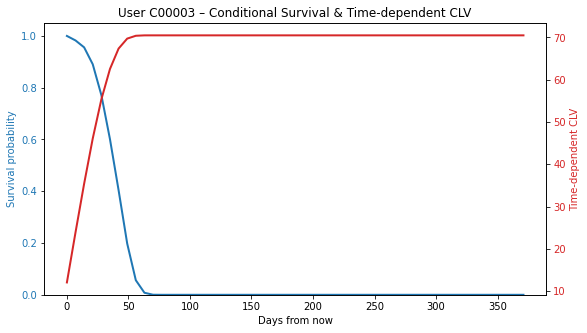

In [52]:
user_id = surv_df["customer_id"].iloc[3]  
idx = surv_df.index[surv_df["customer_id"] == user_id][0]


T_days = 365 
dt = 7
times = np.arange(0, T_days + dt, dt)

X_one = X_surv.iloc[[idx]]
S = surv_model.predict_survival_function(X_one, times=times)

t_grid = S.index.values.astype(float)
S_vals = S.values.flatten()

study_end = df_txn["transaction_date"].max()
age_now = (study_end - surv_df.loc[idx, "first_tx"]).days

S_at_a = np.interp(age_now, t_grid, S_vals)
S_at_a = max(S_at_a, 1e-10)

future_times = times
S_cond = np.interp(age_now + future_times, t_grid, S_vals) / S_at_a


lambda_i = surv_df.loc[idx, "lambda_per_day"]
m_i = surv_df.loc[idx, "monetary_value"]

annual_discount_rate = 0.10
discount = 1 / ((1 + annual_discount_rate) ** (future_times / 365))

cashflow_t = S_cond * lambda_i * m_i * discount
clv_curve = np.cumsum(cashflow_t) * dt   # tích phân rời rạc

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(future_times, S_cond, color="tab:blue", lw=2)
ax1.set_xlabel("Days from now")
ax1.set_ylabel("Survival probability", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.plot(future_times, clv_curve, color="tab:red", lw=2)
ax2.set_ylabel("Time-dependent CLV", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title(f"User {user_id} – Conditional Survival & Time-dependent CLV")
plt.show()

# Log

In [54]:
out = surv_df[[
        "customer_id",
        "expected_remaining_lifetime",
        "monetary_value",
        "lambda_per_day",
        "clv_time_dependent"
]]

out.to_parquet(
    ART_SCORES / "survival_gamma_gamma_clv.parquet")